In [1]:
import os
import cv2
from imutils import paths
import numpy as np
from sklearn.preprocessing import LabelBinarizer

In [5]:
dataPath = "data_set"
outputmodel = "imageclassificationModel"
outputlabelbinarizer = "imageclassificationBinarizer"
epoch = 20

In [6]:
Sports_Labels =  set(['Bacterial _diseases_  Aeromoniasis','Bacterial _Red_ disease',
                      'Bacterial_ gill_ disease','Fungal _diseases _Saprolegniasis','Healthy _Fish',  
                      'Parasitic _diseases', 'Viral_ diseases_ Whitetail _disease'])
Sports_Labels.update([])
print("Images is being loading....")
pathToImages  = list(paths.list_images(dataPath))
data = []
labels = []


for images in pathToImages:
    label = images.split(os.path.sep)[-2]
    
    if label not in Sports_Labels:
        continue
    
    
    image = cv2.imread(images)
    
    if image is None:
        print(f"Error : Unable to load image at path {images}")
        continue
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    image = cv2.resize(image,(244,244))
    data.append(image)
    labels.append(label)
print("Images loaded auccessfully")

Images is being loading....
Images loaded auccessfully


In [7]:
data = np.array(data)
labels = np.array(labels)


In [8]:
lb = LabelBinarizer()

In [9]:
labels = lb.fit_transform(labels)

In [10]:
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import ImageDataGenerator

In [11]:
(X_train,x_test,Y_train,y_test) = train_test_split(data,labels,test_size=0.25,stratify=labels,random_state=42)


In [12]:
trainingAugmentation = ImageDataGenerator(
    rotation_range = 30,
    zoom_range = 0.15,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.15,
    horizontal_flip = True,
    fill_mode = "nearest"   
)

validationAugmentation = ImageDataGenerator()
mean = np.array([123.68,116.779,103.939], dtype="float32")
trainingAugmentation.mean = mean
validationAugmentation.mean = mean

In [13]:
from keras.applications import resnet
from tensorflow.keras.layers import AveragePooling2D, Dropout, Flatten, Dense
from keras.applications import ResNet50

from keras.layers import Input

from keras.models import Model

In [14]:

baseModel = ResNet50(weights="imagenet", include_top=False, input_tensor=Input(shape=(224,244,3)))

headModel = baseModel.output

headModel = AveragePooling2D(pool_size=(7,7))(headModel)
headModel = Flatten(name="flatten")(headModel)
headModdel = Dense(512, activation="relu")(headModel)
headModel = Dropout(0.5)(headModel)
headModel = Dense(len(lb.classes_), activation="softmax")(headModel)

model = Model(inputs = baseModel.input, outputs=headModel)


for baseModelLayers in baseModel.layers:
    baseModelLayers.trainable = False

In [15]:
from keras.optimizers import SGD
import tensorflow as tf


In [16]:
tf.keras.optimizers.legacy.SGD

keras.src.optimizers.legacy.gradient_descent.SGD

In [17]:
opt = tf.keras.optimizers.legacy.Adam(learning_rate=0.0005)

In [18]:
model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

In [19]:
History = model.fit_generator(
    trainingAugmentation.flow(X_train,Y_train, batch_size=32),
    steps_per_epoch=len(X_train)//32,
    validation_data=validationAugmentation.flow(x_test,y_test),
    validation_steps=len(x_test)//32,
    epochs=epoch )

Epoch 1/20


/var/folders/jb/y7llcf5s5vzgmk9vhszgtjfr0000gn/T/ipykernel_1181/2795173487.py:1: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  History = model.fit_generator(


10/10 [==============================] - 14s 1s/step - loss: 2.8570 - accuracy: 0.2452 - val_loss: 1.9595 - val_accuracy: 0.3958
Epoch 2/20
10/10 [==============================] - 13s 1s/step - loss: 2.3563 - accuracy: 0.3323 - val_loss: 1.6234 - val_accuracy: 0.4583
Epoch 3/20
10/10 [==============================] - 14s 1s/step - loss: 2.0680 - accuracy: 0.3387 - val_loss: 1.4106 - val_accuracy: 0.5833
Epoch 4/20
10/10 [==============================] - 14s 1s/step - loss: 1.8501 - accuracy: 0.3969 - val_loss: 1.3749 - val_accuracy: 0.5417
Epoch 5/20
10/10 [==============================] - 15s 2s/step - loss: 1.7058 - accuracy: 0.4250 - val_loss: 1.2979 - val_accuracy: 0.5417
Epoch 6/20
10/10 [==============================] - 15s 2s/step - loss: 1.5866 - accuracy: 0.5484 - val_loss: 1.1097 - val_accuracy: 0.6354
Epoch 7/20
10/10 [==============================] - 15s 2s/step - loss: 1.5230 - accuracy: 0.4839 - val_loss: 1.1090 - val_accuracy: 0.6250
Epoch 8/20
10/10 [=============

In [20]:
History.history

{'loss': [2.856999397277832,
  2.3563499450683594,
  2.0680341720581055,
  1.8500992059707642,
  1.7057631015777588,
  1.5866148471832275,
  1.5230457782745361,
  1.3764666318893433,
  1.4147623777389526,
  1.1771457195281982,
  1.2369862794876099,
  1.108018398284912,
  1.1388744115829468,
  1.1009150743484497,
  1.0011873245239258,
  0.9394848346710205,
  1.0058046579360962,
  0.9146572947502136,
  0.9178959131240845,
  0.8820967078208923],
 'accuracy': [0.2451612949371338,
  0.33225807547569275,
  0.33870968222618103,
  0.3968749940395355,
  0.42500001192092896,
  0.5483871102333069,
  0.4838709533214569,
  0.559374988079071,
  0.551612913608551,
  0.6156250238418579,
  0.5774193406105042,
  0.6193548440933228,
  0.5903225541114807,
  0.637499988079071,
  0.6451612710952759,
  0.6903225779533386,
  0.6580645442008972,
  0.6935483813285828,
  0.6935483813285828,
  0.699999988079071],
 'val_loss': [1.9594507217407227,
  1.6234016418457031,
  1.4106398820877075,
  1.3749386072158813,
 

In [21]:
import numpy as np
from matplotlib import pyplot as plt

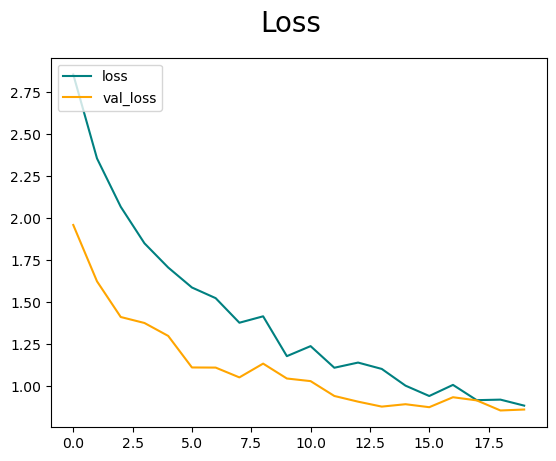

In [22]:
fig = plt.figure()
plt.plot(History.history['loss'], color='teal', label='loss')
plt.plot(History.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

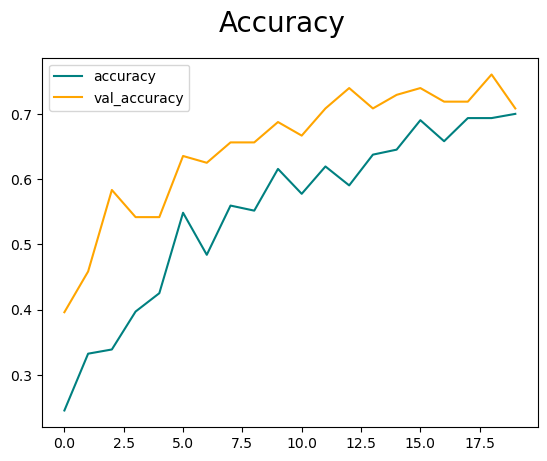

In [23]:
fig = plt.figure()
plt.plot(History.history['accuracy'], color='teal', label='accuracy')
plt.plot(History.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

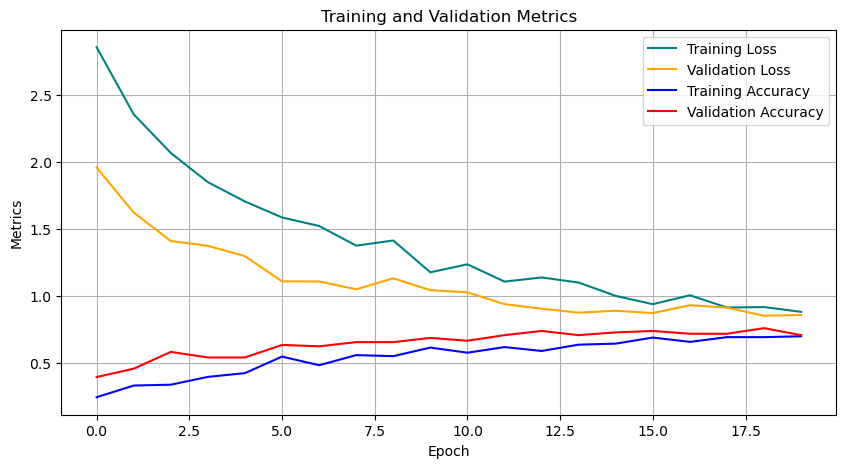

In [24]:
import matplotlib.pyplot as plt

# Plot loss and accuracy on the same graph
plt.figure(figsize=(10, 5))

# Plot loss
plt.plot(History.history['loss'], color='teal', label='Training Loss')
plt.plot(History.history['val_loss'], color='orange', label='Validation Loss')

# Plot accuracy
plt.plot(History.history['accuracy'], color='blue',  label='Training Accuracy')
plt.plot(History.history['val_accuracy'], color='red', label='Validation Accuracy')

plt.title('Training and Validation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Metrics')
plt.legend()
plt.grid(True)
plt.show()


In [25]:
training_loss = History.history['loss']
validation_loss = History.history['val_loss']


training_accuracy = History.history['accuracy']
validation_accuracy = History.history['val_accuracy']


print("Training Loss:", training_loss[-1])
print("Validation Loss:", validation_loss[-1])

# Printing the final accuracy metrics
print("Training Accuracy:", training_accuracy[-1])
print("Validation Accuracy:", validation_accuracy[-1])


Training Loss: 0.8820967078208923
Validation Loss: 0.8588838577270508
Training Accuracy: 0.699999988079071
Validation Accuracy: 0.7083333134651184
